# pyqes Optimization Demo

Minimal end-to-end example: connect, upload data, run a mean-variance optimization, read the results.

For the full API surface (all constraints, factor neutralization, ADV, TCM, etc.) see [`pyqes_optimization_guide.md`](./pyqes_optimization_guide.md).

**Before running:**

1. Install [uv](https://docs.astral.sh/uv/): `curl -LsSf https://astral.sh/uv/install.sh | sh`
2. `uv sync` in this directory
3. Select `./.venv/bin/python` as the notebook kernel (or launch with `uv run jupyter lab`)
4. Copy `.env.example` to `.env` and fill in your QES username and password

In [57]:
import os
from dotenv import load_dotenv
from pyqes import micsvc

load_dotenv()

connection = micsvc.Connection(
    username=os.environ['QES_USERNAME'],
    password=os.environ['QES_PASSWORD'],
)
optimizer = connection.get_optimizer()

In [58]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Broad US large-cap universe across all 11 GICS sectors.
# Swap for SP500 / Russell 1000 / your own list — the optimizer's universe IS this DataFrame.
tickers = [
    # Info Tech
    'AAPL', 'MSFT', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO', 'ACN', 'IBM',
    'INTC', 'AMD', 'TXN', 'QCOM', 'NOW', 'INTU', 'MU', 'AMAT', 'LRCX', 'ADI',
    # Communication Services
    'GOOGL', 'META', 'NFLX', 'DIS', 'T', 'VZ', 'TMUS', 'CMCSA', 'CHTR', 'EA',
    # Consumer Discretionary
    'AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'BKNG', 'TJX',
    # Consumer Staples
    'WMT', 'PG', 'KO', 'PEP', 'COST', 'MDLZ', 'PM', 'MO', 'CL', 'KMB',
    # Financials
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'AXP', 'C', 'SCHW', 'USB',
    'PNC', 'SPGI', 'MMC', 'AIG',
    # Health Care
    'JNJ', 'UNH', 'LLY', 'PFE', 'ABBV', 'MRK', 'TMO', 'ABT', 'DHR', 'AMGN',
    'CVS', 'BMY', 'GILD', 'CI',
    # Industrials
    'CAT', 'BA', 'HON', 'UPS', 'RTX', 'GE', 'LMT', 'DE', 'UNP', 'NOC', 'EMR',
    # Energy
    'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PSX', 'MPC', 'VLO', 'OXY',
    # Materials
    'LIN', 'SHW', 'APD', 'ECL', 'FCX', 'NEM', 'DD', 'DOW',
    # Real Estate
    'PLD', 'AMT', 'EQIX', 'CCI', 'PSA', 'WELL',
    # Utilities
    'NEE', 'SO', 'DUK', 'AEP', 'SRE', 'XEL',
]
dates = ['2023-01-03', '2023-01-04']
bench_w = 1.0 / len(tickers)

data = pd.DataFrame([
    {'TICKER': t, 'DATE': d, 'Alpha': np.random.normal(0.02, 0.01), 'Benchmark': bench_w}
    for d in dates for t in tickers
])
print(f'{len(tickers)} tickers × {len(dates)} dates = {len(data)} rows')
data.head()

117 tickers × 2 dates = 234 rows


,TICKER,DATE,Alpha,Benchmark
0,AAPL,2023-01-03,0.024967,0.008547
1,MSFT,2023-01-03,0.018617,0.008547
2,NVDA,2023-01-03,0.026477,0.008547
3,AVGO,2023-01-03,0.035230,0.008547
4,ORCL,2023-01-03,0.017658,0.008547


In [59]:
optimizer.set_user_data(name='demo_alpha_data', data=data, overwrite=True)

optimizer.set_template('default')
optimizer.set_objective('MVO')
optimizer.set_risk_model('QES_US_AC_2')
optimizer.set_alpha('Alpha')
optimizer.set_lambda(2.5)
optimizer.set_benchmark('Benchmark')

# Long-only, fully invested. The 'default' template resolves to 'us-example' on the server,
# which defaults to a 100/100 long-short book — override to long-only or the problem is infeasible.
optimizer.set_bounds(lb=0.0, ub=0.10)
optimizer.set_min_long_weight(1.0)
optimizer.set_max_long_weight(1.0)
optimizer.set_min_short_weight(0.0)
optimizer.set_max_short_weight(0.0)

Calling Uploading /tmp/tmpm2mb5w0c.csv to demo_alpha_data ...
Portfolio Uploaded successfully


In [60]:
optimizer.submit()
optimizer.wait(max_wait_secs=300)

status = optimizer.status()
print(f'Status: {status}')

if status != 'SUCCESS':
    print(optimizer.get_logs())

Status: SUCCESS


In [61]:
results = optimizer.get_results()

mapping = results.sym_mapping()
# sym_mapping has one row per (ticker, date); dedupe on INPUTID for the count.
print(f'\n{mapping.INPUTID.nunique()} / {len(tickers)} tickers mapped')
mapping


117 / 117 tickers mapped


,INPUTID,INPUTSTARTDATE,INPUTENDDATE,QESID,QESSTARTDATE,QESENDDATE,MESSAGE,ADJUSTMENT
1,AAPL,2023-01-03,2100-01-01,1690.01,1986-12-14,2900-01-01,Good Match,NaN
2,MSFT,2023-01-03,2100-01-01,12141.01,1986-12-14,2900-01-01,Good Match,NaN
3,NVDA,2023-01-03,2100-01-01,117768.01,1999-01-22,2900-01-01,Good Match,NaN
4,AVGO,2023-01-03,2100-01-01,180711.01,2008-08-25,2900-01-01,Good Match,NaN
5,ORCL,2023-01-03,2100-01-01,12142.01,1986-12-14,2900-01-01,Good Match,NaN
...,...,...,...,...,...,...,...,...
230,SO,2023-01-04,2100-01-01,9850.01,1986-12-14,2900-01-01,Good Match,NaN
231,DUK,2023-01-04,2100-01-01,4093.01,1986-12-14,2900-01-01,Good Match,NaN
232,AEP,2023-01-04,2100-01-01,1440.01,1986-12-14,2900-01-01,Good Match,NaN
233,SRE,2023-01-04,2100-01-01,8272.01,1998-06-29,2900-01-01,Good Match,NaN


In [62]:
# Weights come back indexed by the server's internal QESID. Join with sym_mapping to get tickers back.
qesid_to_ticker = results.sym_mapping().drop_duplicates('QESID').set_index('QESID')['INPUTID']
weights = results.get_weights().rename(index=qesid_to_ticker)

print('Ex-ante risk:')
print(results.get_risk())
print('\nEx-ante alpha:')
print(results.get_alpha())
print('\nTop 10 weights on first date:')
weights.iloc[:, 0].sort_values(ascending=False).head(10)

Ex-ante risk:
                   x
2023-01-03  0.215580
2023-01-04  0.214801

Ex-ante alpha:
                   x
2023-01-03  0.030286
2023-01-04  0.032773

Top 10 weights on first date:


AVGO     0.038547
GOOGL    0.038547
ADBE     0.038547
CVS      0.038547
PNC      0.038547
DUK      0.038547
GE       0.038547
AMT      0.038547
CL       0.037248
DHR      0.033891
Name: 2023-01-03, dtype: float64

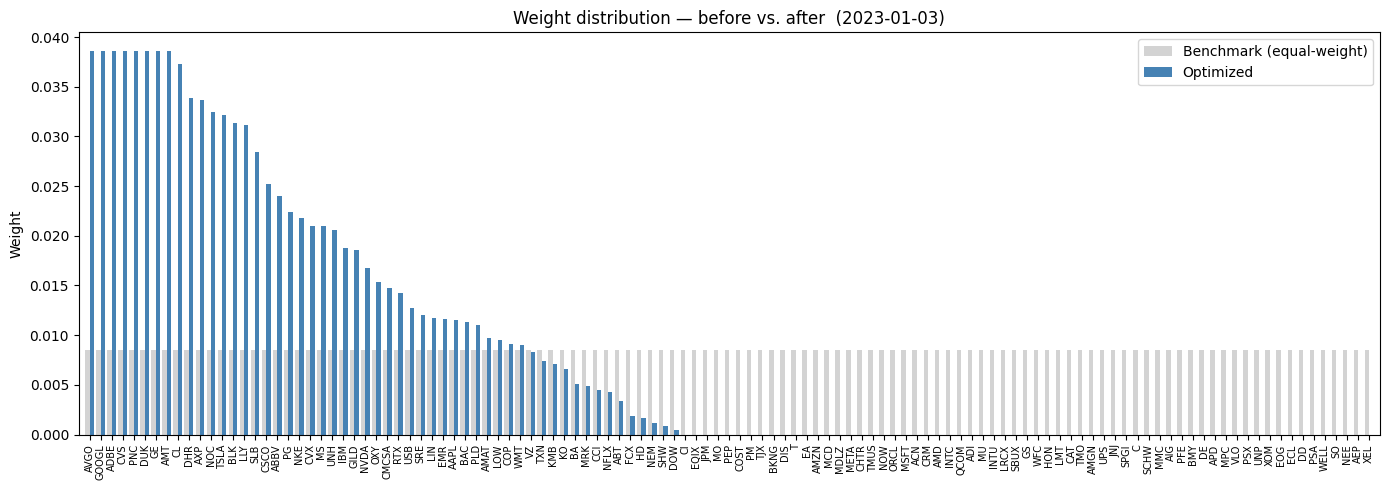

In [63]:
import matplotlib.pyplot as plt

date = weights.columns[0]
opt_w = weights[date].sort_values(ascending=False)
bench_by_ticker = data[data.DATE == date].set_index('TICKER')['Benchmark'].reindex(opt_w.index)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(opt_w))
ax.bar(x - 0.2, bench_by_ticker.values, width=0.4, label='Benchmark (equal-weight)', color='lightgray')
ax.bar(x + 0.2, opt_w.values, width=0.4, label='Optimized', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(opt_w.index, rotation=90, fontsize=7)
ax.set_ylabel('Weight')
ax.set_title(f'Weight distribution — before vs. after  ({date})')
ax.legend()
ax.margins(x=0.005)
plt.tight_layout()
plt.show()